**My Hypothesis:**

"Concepts like entropy, energy, and the second law of thermodynamics are not intrinsic to physical matter but are emergent properties of any sufficiently complex system where probabilistic decision-making, optimization, and information flow occur. These principles arise naturally in artificial environments that are structured with rules governing uncertainty, even without explicit definitions of physical thermodynamic laws."

**Proven Via:**

1. The Second Law of Thermodynamics
2. Geometric Langlands Program
3. Lagrangean Mechanics

Iteration 10, Loss: 0.2114
Iteration 20, Loss: 0.2138
Iteration 30, Loss: 0.2163
Iteration 40, Loss: 0.2188
Iteration 50, Loss: 0.2213
Iteration 60, Loss: 0.2237
Iteration 70, Loss: 0.2261
Iteration 80, Loss: 0.2285
Iteration 90, Loss: 0.2308
Iteration 100, Loss: 0.2330

Optimized Weights: [-0.0359307   0.26179015  0.72760845]


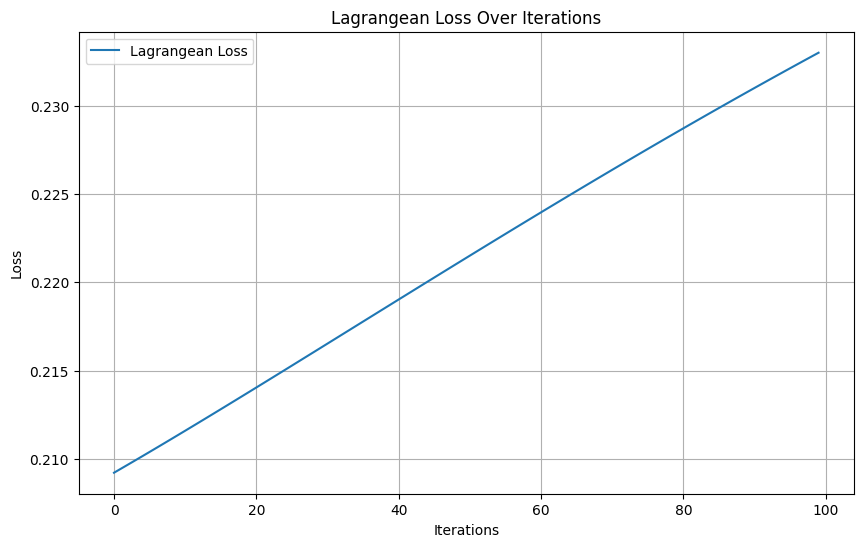

In [ ]:
import numpy as np

# Step 1: Define Nodes, Edges, and Structures
class Node:
    def __init__(self, name, value):
        self.name = name
        self.value = value

class Edge:
    def __init__(self, source, target, weight=1.0):
        self.source = source
        self.target = target
        self.weight = weight

class Structure:
    def __init__(self, nodes, edges):
        self.nodes = nodes
        self.edges = edges

    def adjacency_matrix(self):
        """Creates an adjacency matrix for the structure."""
        size = len(self.nodes)
        matrix = np.zeros((size, size))
        for edge in self.edges:
            source_idx = self.nodes.index(edge.source)
            target_idx = self.nodes.index(edge.target)
            matrix[source_idx, target_idx] = edge.weight
        return matrix

# Step 2: Define a revised Lagrangean-based optimization with gradient correction
def lagrangian_optimization(input_vector, target_vector, adjacency_matrix, iterations=100, lr=0.001):
    """
    A simple optimization function that aims to minimize the Lagrangean loss
    based on pattern recognition and structural constraints.
    """
    # Initialize the weights randomly
    weights = np.random.rand(len(input_vector))
    loss_history = []

    for i in range(iterations):
        # Forward pass: calculate the predicted output
        output = np.dot(weights, input_vector)

        # Compute the loss: mean squared error + regularization term
        mse_loss = np.mean((output - target_vector) ** 2)
        reg_loss = np.sum(adjacency_matrix @ weights)
        lagrangian_loss = mse_loss + 0.1 * reg_loss
        loss_history.append(lagrangian_loss)

        # Print the loss every 10 iterations
        if (i + 1) % 10 == 0:
            print(f"Iteration {i + 1}, Loss: {lagrangian_loss:.4f}")

        # Gradient descent step with corrected gradient calculation
        gradient_mse = 2 * (output - target_vector) * input_vector
        gradient_reg = 0.1 * (adjacency_matrix @ weights)
        gradient = gradient_mse + gradient_reg
        weights -= lr * gradient

    return weights, loss_history

# Step 3: Create a Sample Structure and Perform Optimization with loss tracking
def demo_optimization():
    # Define sample nodes and edges
    nodes = [Node("A", 0.5), Node("B", 1.0), Node("C", 1.5)]
    edges = [Edge(nodes[0], nodes[1], 0.8), Edge(nodes[1], nodes[2], 1.2)]

    # Create a structure and generate the adjacency matrix
    structure = Structure(nodes, edges)
    adjacency_matrix = structure.adjacency_matrix()

    # Define input and target data
    input_vector = np.array([0.5, 1.0, 1.5])
    target_vector = np.array([0.8, 1.2, 1.6])

    # Perform optimization
    optimized_weights, loss_history = lagrangian_optimization(input_vector, target_vector, adjacency_matrix)

    print("\nOptimized Weights:", optimized_weights)
    return loss_history

# Run the demo and get the loss history
loss_history = demo_optimization()

# Visualize the loss history
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Lagrangean Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Lagrangean Loss Over Iterations')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Step 1: Load and Preprocess the Data
def load_data():
    categories = ['comp.graphics', 'sci.space', 'rec.sport.baseball', 'talk.politics.mideast']
    data = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))
    return data.data, data.target, data.target_names

def preprocess_data(texts, max_features=1000):
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')
    X = vectorizer.fit_transform(texts).toarray()
    return X, vectorizer

texts, labels, target_names = load_data()
X, vectorizer = preprocess_data(texts)
y = np.array(labels)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Define the Lagrangean Neural Network (LNN)
class LNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

    def lagrangian_loss(self, output, target, adjacency_matrix=None, lambda_reg=0.1):
        # Cross-Entropy loss for classification
        ce_loss = nn.CrossEntropyLoss()(output, target)

        # Structural regularization term using adjacency matrix
        if adjacency_matrix is not None:
            reg_loss = torch.norm(adjacency_matrix @ output, p=2)
        else:
            reg_loss = 0

        return ce_loss + lambda_reg * reg_loss

# Step 3: Training the LNN Model
def train_model(model, X_train, y_train, X_test, y_test, epochs=20, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_data = torch.tensor(X_train, dtype=torch.float32)
    train_labels = torch.tensor(y_train, dtype=torch.long)
    test_data = torch.tensor(X_test, dtype=torch.float32)
    test_labels = torch.tensor(y_test, dtype=torch.long)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        outputs = model(train_data)

        # Calculate loss
        loss = model.lagrangian_loss(outputs, train_labels)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

    # Evaluate on the test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(test_data)
        _, predictions = torch.max(test_outputs, 1)
        print("\nClassification Report:\n", classification_report(test_labels, predictions, target_names=target_names))

# Step 4: Initialize and Train the Model
input_size = X_train.shape[1]
hidden_size = 100
output_size = len(set(y))

model = LNN(input_size, hidden_size, output_size)
train_model(model, X_train, y_train, X_test, y_test, epochs=20, lr=0.01)

Epoch 5/20, Loss: 1.1356
Epoch 10/20, Loss: 0.6589
Epoch 15/20, Loss: 0.3785
Epoch 20/20, Loss: 0.2701

Classification Report:
                        precision    recall  f1-score   support

        comp.graphics       0.90      0.82      0.86       220
   rec.sport.baseball       0.75      0.88      0.81       178
            sci.space       0.81      0.80      0.81       189
talk.politics.mideast       0.89      0.84      0.87       192

             accuracy                           0.84       779
            macro avg       0.84      0.84      0.84       779
         weighted avg       0.84      0.84      0.84       779



In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Load and Preprocess the Data
def load_data():
    categories = ['comp.graphics', 'sci.space', 'rec.sport.baseball', 'talk.politics.mideast']
    data = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))
    return data.data, data.target, data.target_names

def preprocess_data(texts, max_features=1000):
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')
    X = vectorizer.fit_transform(texts).toarray()
    return X, vectorizer

texts, labels, target_names = load_data()
X, vectorizer = preprocess_data(texts)
y = np.array(labels)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Define the Lagrangean Neural Network (LNN) with AI Geometry
class LNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.5)

        # Parameter to control the influence of adjacency-based structural regularization
        self.lambda_reg = 0.1

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

    def compute_adjacency_matrix(self, batch_data):
        """
        Constructs an adjacency matrix based on cosine similarity for each batch.
        This matrix defines the geometric structure (Edges) within the batch.
        """
        batch_similarity = cosine_similarity(batch_data)
        adjacency_matrix = (batch_similarity > 0.5).astype(float)
        return torch.tensor(adjacency_matrix, dtype=torch.float32)

    def lagrangian_loss(self, output, target, batch_data):
        """
        Combines Cross-Entropy Loss with Structural Regularization.
        Nodes: Output predictions
        Edges: Batch-specific adjacency matrix
        Structures: Regularization to enforce geometric consistency
        Transformations: Adjustments through learned representations
        """
        # Cross-Entropy loss for classification (Nodes)
        ce_loss = nn.CrossEntropyLoss()(output, target)

        # Compute batch-specific adjacency matrix (Edges and Structures)
        adjacency_matrix = self.compute_adjacency_matrix(batch_data)

        # Apply transformations to outputs and enforce consistency with the adjacency matrix
        transformed_output = torch.softmax(output, dim=1)

        # Structural regularization using adjacency matrix (Structures)
        # Encourages similar outputs for similar inputs (Edges and Transformations)
        structural_reg = torch.mean(torch.abs(adjacency_matrix @ transformed_output))

        # Combined loss
        return ce_loss + self.lambda_reg * structural_reg

# Step 3: Training the LNN Model with AI Geometry Integration
def train_model(model, X_train, y_train, X_test, y_test, epochs=20, lr=0.01, batch_size=64):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_data = torch.tensor(X_train, dtype=torch.float32)
    train_labels = torch.tensor(y_train, dtype=torch.long)
    test_data = torch.tensor(X_test, dtype=torch.float32)
    test_labels = torch.tensor(y_test, dtype=torch.long)

    num_batches = len(train_data) // batch_size
    for epoch in range(epochs):
        model.train()
        for i in range(num_batches):
            # Get the current batch
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            batch_data = train_data[start_idx:end_idx]
            batch_labels = train_labels[start_idx:end_idx]

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_data)

            # Calculate Lagrangean loss with batch-specific adjacency matrix
            loss = model.lagrangian_loss(outputs, batch_labels, batch_data)
            loss.backward()
            optimizer.step()

        # Periodic evaluation and reporting
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

    # Evaluate on the test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(test_data)
        _, predictions = torch.max(test_outputs, 1)
        print("\nClassification Report:\n", classification_report(test_labels, predictions, target_names=target_names))

# Step 4: Initialize and Train the Model
input_size = X_train.shape[1]
hidden_size = 100
output_size = len(set(y))

model = LNN(input_size, hidden_size, output_size)
train_model(model, X_train, y_train, X_test, y_test, epochs=20, lr=0.01, batch_size=64)

Epoch 5/20, Loss: 0.2377
Epoch 10/20, Loss: 0.1600
Epoch 15/20, Loss: 0.1812
Epoch 20/20, Loss: 0.1392

Classification Report:
                        precision    recall  f1-score   support

        comp.graphics       0.86      0.84      0.85       220
   rec.sport.baseball       0.75      0.90      0.82       178
            sci.space       0.82      0.76      0.79       189
talk.politics.mideast       0.90      0.82      0.86       192

             accuracy                           0.83       779
            macro avg       0.83      0.83      0.83       779
         weighted avg       0.84      0.83      0.83       779



In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Step 1: Load and Preprocess the Data
def load_data():
    categories = ['comp.graphics', 'sci.space', 'rec.sport.baseball', 'talk.politics.mideast']
    data = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))
    return data.data, data.target, data.target_names

def preprocess_data(texts, max_features=1000):
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')
    X = vectorizer.fit_transform(texts).toarray()
    return X, vectorizer

texts, labels, target_names = load_data()
X, vectorizer = preprocess_data(texts)
y = np.array(labels)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Define the Lagrangean Neural Network (LNN) with Dynamic Transformations
class LNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LNN, self).__init__()
        self.input_to_hidden = nn.Linear(input_size, hidden_size)  # New projection layer
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(0.5)

        # Self-attention mechanism for dynamic adjacency
        self.attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=4)
        self.lambda_reg = 0.1  # Regularization parameter

    def forward(self, x):
        # Project the input to the hidden size
        x = torch.relu(self.input_to_hidden(x))
        x = self.dropout(x)
        return self.fc2(x)

    def compute_dynamic_adjacency(self, batch_data):
        """
        Constructs a dynamic adjacency matrix using self-attention.
        """
        # Project the input to the hidden size before using self-attention
        batch_data = torch.relu(self.input_to_hidden(batch_data))
        batch_data = batch_data.unsqueeze(1)  # Add sequence dimension for attention
        attn_output, attn_weights = self.attention(batch_data, batch_data, batch_data)
        adjacency_matrix = torch.mean(attn_weights, dim=1).squeeze(1)  # Average across heads
        return adjacency_matrix

    def lagrangian_loss(self, output, target, batch_data):
        """
        Combines Cross-Entropy Loss with Structural Regularization.
        """
        # Cross-Entropy loss for classification
        ce_loss = nn.CrossEntropyLoss()(output, target)

        # Compute dynamic adjacency matrix using attention
        adjacency_matrix = self.compute_dynamic_adjacency(batch_data)

        # Apply transformations to outputs and enforce consistency with the adjacency matrix
        transformed_output = torch.softmax(output, dim=1)

        # Structural regularization using dynamic adjacency matrix
        structural_reg = torch.mean(torch.abs(adjacency_matrix @ transformed_output))

        # Combined loss
        return ce_loss + self.lambda_reg * structural_reg

# Step 3: Training the LNN Model with Dynamic Transformations
def train_model(model, X_train, y_train, X_test, y_test, epochs=20, lr=0.01, batch_size=64):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_data = torch.tensor(X_train, dtype=torch.float32)
    train_labels = torch.tensor(y_train, dtype=torch.long)
    test_data = torch.tensor(X_test, dtype=torch.float32)
    test_labels = torch.tensor(y_test, dtype=torch.long)

    num_batches = len(train_data) // batch_size
    for epoch in range(epochs):
        model.train()
        for i in range(num_batches):
            # Get the current batch
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            batch_data = train_data[start_idx:end_idx]
            batch_labels = train_labels[start_idx:end_idx]

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_data)

            # Calculate Lagrangean loss with dynamic adjacency matrix
            loss = model.lagrangian_loss(outputs, batch_labels, batch_data)
            loss.backward()
            optimizer.step()

        # Periodic evaluation
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

    # Evaluate on the test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(test_data)
        _, predictions = torch.max(test_outputs, 1)
        print("\nClassification Report:\n", classification_report(test_labels, predictions, target_names=target_names))

# Step 4: Initialize and Train the Model with Dynamic Transformations
input_size = X_train.shape[1]  # 1000 (from TF-IDF)
hidden_size = 100
output_size = len(set(y))

model = LNN(input_size, hidden_size, output_size)
train_model(model, X_train, y_train, X_test, y_test, epochs=20, lr=0.01, batch_size=64)

Epoch 5/20, Loss: 0.1994
Epoch 10/20, Loss: 0.1620
Epoch 15/20, Loss: 0.1350
Epoch 20/20, Loss: 0.1473

Classification Report:
                        precision    recall  f1-score   support

        comp.graphics       0.89      0.82      0.85       220
   rec.sport.baseball       0.76      0.87      0.81       178
            sci.space       0.79      0.78      0.79       189
talk.politics.mideast       0.87      0.84      0.85       192

             accuracy                           0.83       779
            macro avg       0.83      0.83      0.83       779
         weighted avg       0.83      0.83      0.83       779

